# Trajectory Analysis for Weight Scan

In [1]:
0

0

In [2]:
import sys
working_directory = "/home/icb/kemal.inecik/work/codes/sctram"
sys.path.append(working_directory)

import logging
import subprocess
import gc
import os
import time
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
import pickle
import itertools
import torch
import tqdm
import scvi
import h5py

sc.settings.verbose = 3

In [3]:
from sctram.api._lower_level import TrajectoryEvaluationAPI
from sctram.generate.real import sc_suo_developmental_complete
from sctram.input import InputTrajectories

2025-05-10 10:30:25.872 | INFO     | sctram.api._defaults_read:load_default_metrics:23 - Loaded default metrics from /home/icb/kemal.inecik/work/codes/sctram/sctram/api/_defaults.yaml
2025-05-10 10:30:25.874 | INFO     | sctram.api._defaults_read:load_default_metrics:79 - Default metrics YAML structure validated successfully.


In [4]:
# Important to have consistent figures across platforms

%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib import gridspec
import matplotlib.pyplot as plt
import seaborn as sns
import colorcet as cc
from adjustText import adjust_text  
import matplotlib.patheffects as path_effects

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [5]:
print(f"CUDA used: {torch.cuda.is_available()}")

dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
helpers_directory = os.path.join(os.getcwd(), "helper")
logs_directory = os.path.join(os.getcwd(), "logs")

CUDA used: True


## Definitions

In [6]:
definitions = dict()

In [7]:
definitions["tardis_sciplex_whole"] = {
    "training_anndata_path": os.path.join(dataset_dir, f"tardis_cpa_sciplex_v2_encode_incremental_training_anndata.h5ad"),
    "vae_path": "placeholder",
    "pickle_paths_path": os.path.join(dataset_dir, f"tardis_cpa_sciplex_v2_encode_weight_scan_latent_paths_whole.pkl"),
    "trajectory_object_path": None,
    "label_obs_column": "drug_dose_name",
    "batch_obs_column": "none",
    # "pickle_indices_path": os.path.join(dataset_dir, f"tardis_cpa_sciplex_v2_encode_incremental_latent_indices.pkl"),
}

definitions["tardis_sciplex_dose"] = {
    "training_anndata_path": os.path.join(dataset_dir, f"tardis_cpa_sciplex_v2_encode_incremental_training_anndata.h5ad"),
    "vae_path": "placeholder",
    "pickle_paths_path": os.path.join(dataset_dir, f"tardis_cpa_sciplex_v2_encode_weight_scan_latent_paths_dose.pkl"),
    "trajectory_object_path": None,
    "label_obs_column": "dose",
    "batch_obs_column": "none",
    # "pickle_indices_path": os.path.join(dataset_dir, f"tardis_cpa_sciplex_v2_encode_incremental_latent_indices.pkl"),
}

### Trajectory `tardis_sciplex_whole`

In [8]:
with h5py.File(definitions["tardis_sciplex_whole"]["training_anndata_path"]) as _file_anndata_training:
    adata_training_obs = ad.io.read_elem(_file_anndata_training["obs"])
with open(definitions["tardis_sciplex_whole"]["pickle_paths_path"], "rb") as _file_pickle_paths:
    pickle_paths = pickle.load(_file_pickle_paths)
latent = ad.read_h5ad(pickle_paths[max(pickle_paths.keys())])
latent.obs = adata_training_obs.copy()
latent

AnnData object with n_obs × n_vars = 14811 × 40
    obs: 'sample', 'size_factor', 'n.umi', 'hash_umis', 'pval', 'qval', 'top_to_second_best_ratio', 'top_oligo', 'drug', 'dose', 'vehicle', 'n_counts', 'log_counts', 'n_genes', 'mt_frac', 'product_dose', 'louvain', 'dose_val', 'cell_type', 'drug_dose_name', 'cov_drug_dose_name', 'condition', 'control', 'split', 'dose_training', '_scvi_batch', '_scvi_labels'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [9]:
node_names = set(sorted(latent.obs[definitions["tardis_sciplex_whole"]["label_obs_column"]].unique()))
ground_truth_trajectories = dict()

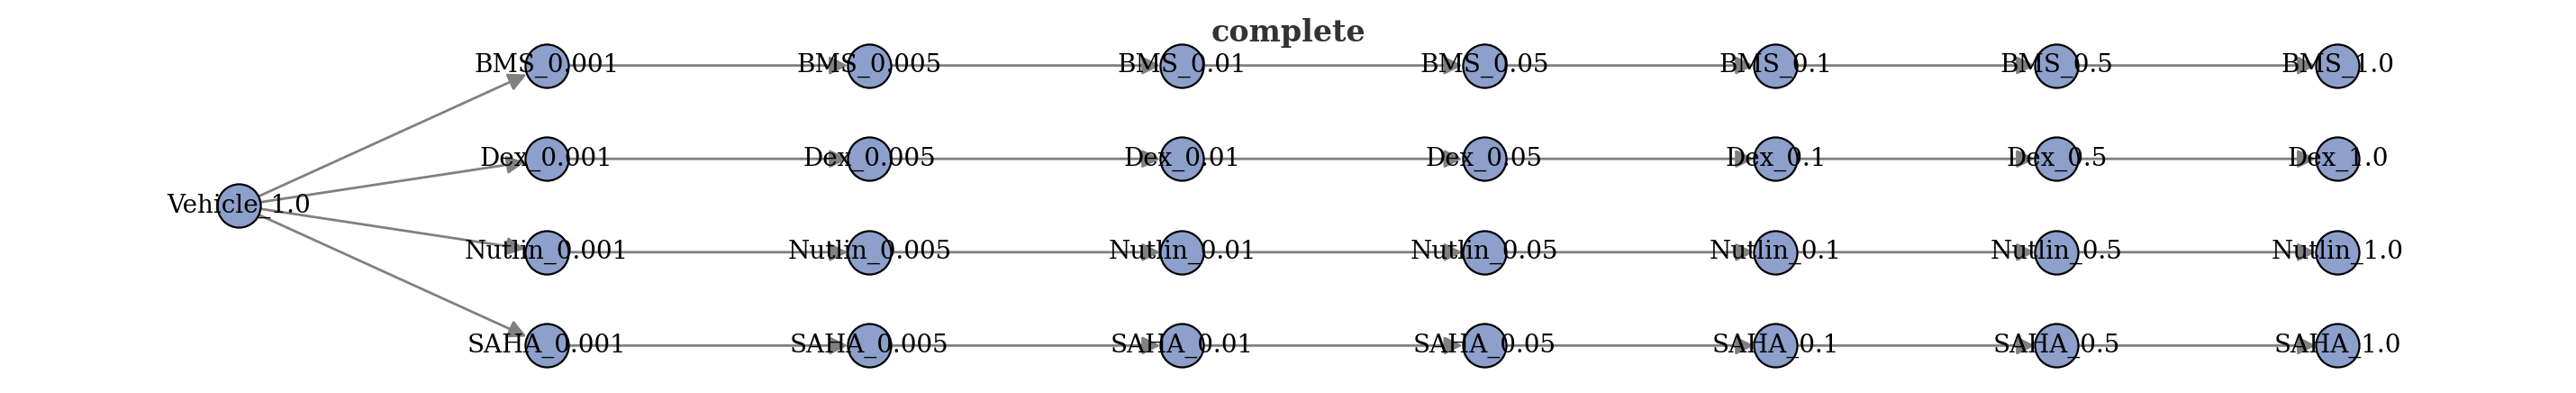

In [10]:
trajectory = "complete"
ground_truth_trajectories[trajectory] = [
    ('Vehicle_1.0', 'BMS_0.001'),
    ('Vehicle_1.0', 'Dex_0.001'),
    ('Vehicle_1.0', 'Nutlin_0.001'),
    ('Vehicle_1.0', 'SAHA_0.001'),
    
    ('BMS_0.001', 'BMS_0.005'),
    ('Dex_0.001', 'Dex_0.005'),
    ('Nutlin_0.001', 'Nutlin_0.005'),
    ('SAHA_0.001', 'SAHA_0.005'),
    
    ('BMS_0.005', 'BMS_0.01'),
    ('Dex_0.005', 'Dex_0.01'),
    ('Nutlin_0.005', 'Nutlin_0.01'),
    ('SAHA_0.005', 'SAHA_0.01'),

    ('BMS_0.01', 'BMS_0.05'),
    ('Dex_0.01', 'Dex_0.05'),
    ('Nutlin_0.01', 'Nutlin_0.05'),
    ('SAHA_0.01', 'SAHA_0.05'),

    ('BMS_0.05', 'BMS_0.1'),
    ('Dex_0.05', 'Dex_0.1'),
    ('Nutlin_0.05', 'Nutlin_0.1'),
    ('SAHA_0.05', 'SAHA_0.1'),

    ('BMS_0.1', 'BMS_0.5'),
    ('Dex_0.1', 'Dex_0.5'),
    ('Nutlin_0.1', 'Nutlin_0.5'),
    ('SAHA_0.1', 'SAHA_0.5'),

    ('BMS_0.5', 'BMS_1.0'),
    ('Dex_0.5', 'Dex_1.0'),
    ('Nutlin_0.5', 'Nutlin_1.0'),
    ('SAHA_0.5', 'SAHA_1.0'),
]
_input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory, include_additional_nodes=False)
_input_trajectory.plot_trajectory(
    title=trajectory,
    figsize=(15, 2), 
    label_offset=0,
)
assert all([i in node_names for i in _input_trajectory.nodes()])

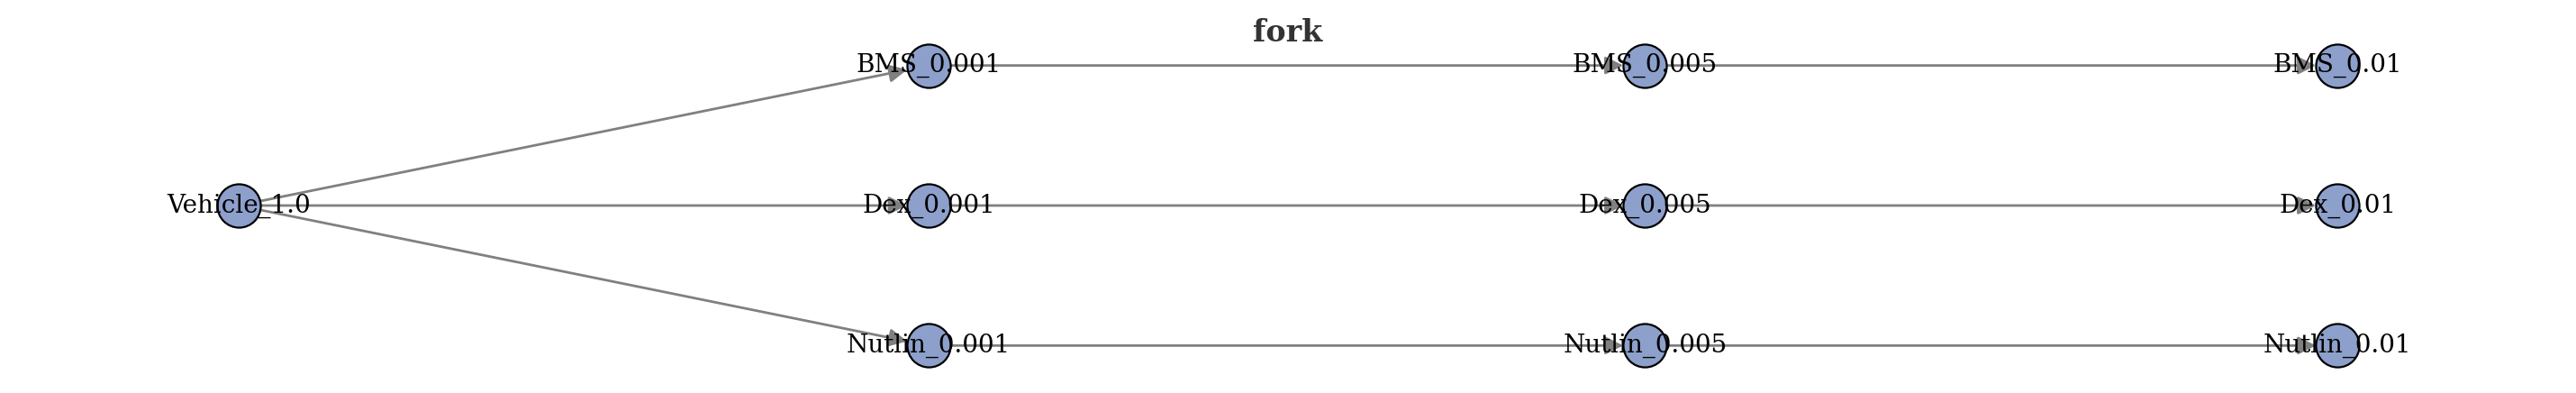

In [11]:
trajectory = "fork"
ground_truth_trajectories[trajectory] = [
    ('Vehicle_1.0', 'BMS_0.001'),
    ('Vehicle_1.0', 'Dex_0.001'),
    ('Vehicle_1.0', 'Nutlin_0.001'),
    
    ('BMS_0.001', 'BMS_0.005'),
    ('Dex_0.001', 'Dex_0.005'),
    ('Nutlin_0.001', 'Nutlin_0.005'),
    
    ('BMS_0.005', 'BMS_0.01'),
    ('Dex_0.005', 'Dex_0.01'),
    ('Nutlin_0.005', 'Nutlin_0.01'),
]
_input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory, include_additional_nodes=False)
_input_trajectory.plot_trajectory(
    title=trajectory,
    figsize=(15, 2), 
    label_offset=0,
)
assert all([i in node_names for i in _input_trajectory.nodes()])

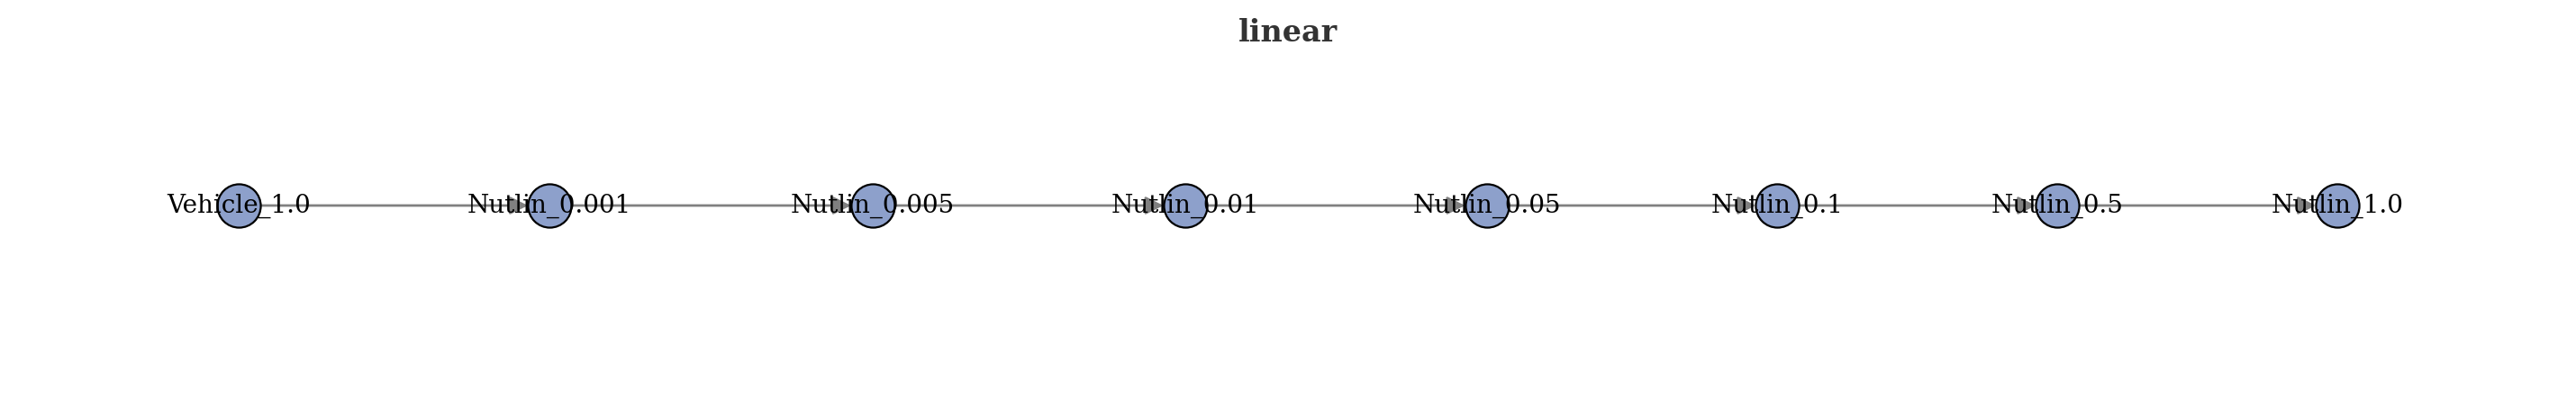

In [12]:
trajectory = "linear"
ground_truth_trajectories[trajectory] = [
    ('Vehicle_1.0', 'Nutlin_0.001'),
    ('Nutlin_0.001', 'Nutlin_0.005'),
    ('Nutlin_0.005', 'Nutlin_0.01'),
    ('Nutlin_0.01', 'Nutlin_0.05'),
    ('Nutlin_0.05', 'Nutlin_0.1'),
    ('Nutlin_0.1', 'Nutlin_0.5'),
    ('Nutlin_0.5', 'Nutlin_1.0'),
]
_input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory, include_additional_nodes=False)
_input_trajectory.plot_trajectory(
    title=trajectory,
    figsize=(15, 2), 
    label_offset=0,
)

assert all([i in node_names for i in _input_trajectory.nodes()])

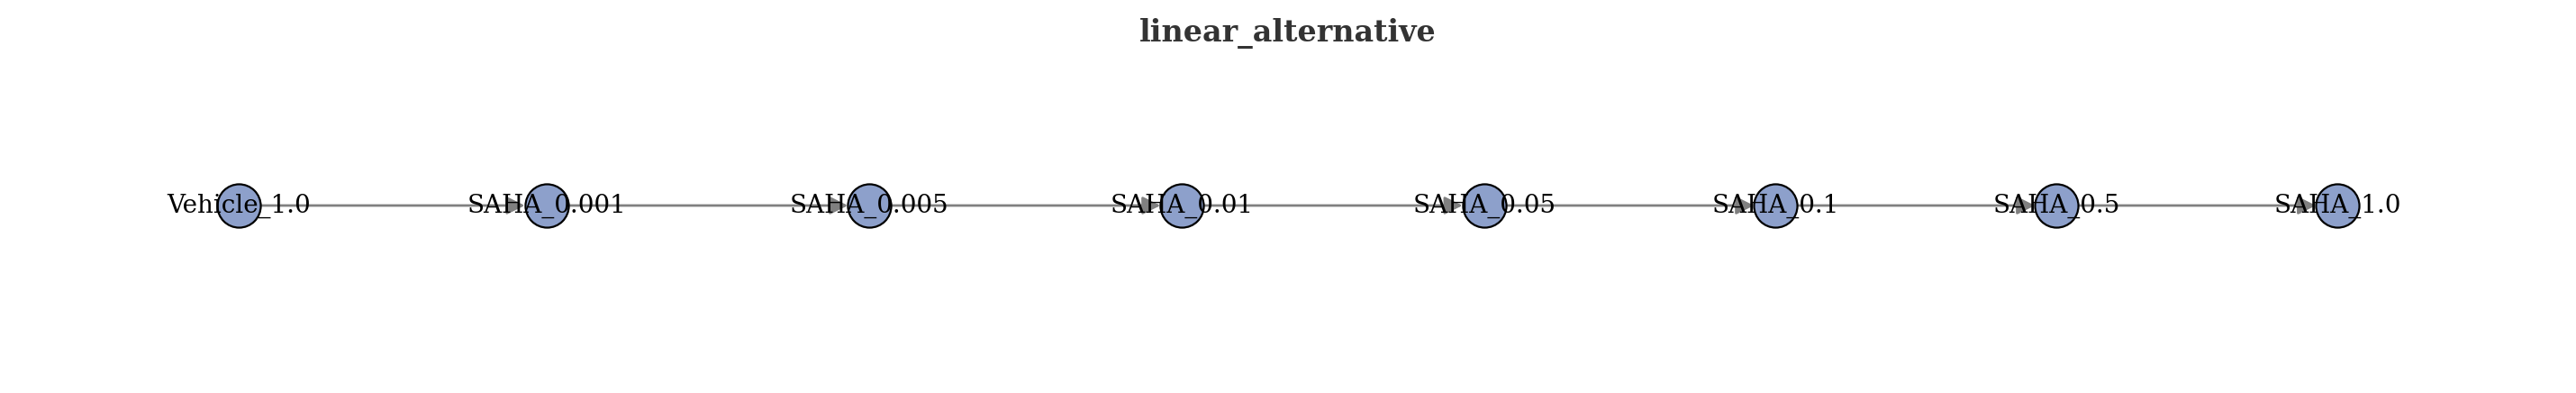

In [13]:
trajectory = "linear_alternative"
ground_truth_trajectories[trajectory] = [
    ('Vehicle_1.0', 'SAHA_0.001'),
    ('SAHA_0.001', 'SAHA_0.005'),
    ('SAHA_0.005', 'SAHA_0.01'),
    ('SAHA_0.01', 'SAHA_0.05'),
    ('SAHA_0.05', 'SAHA_0.1'),
    ('SAHA_0.1', 'SAHA_0.5'),
    ('SAHA_0.5', 'SAHA_1.0'),
]
_input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory, include_additional_nodes=False)
_input_trajectory.plot_trajectory(
    title=trajectory,
    figsize=(15, 2), 
    label_offset=0,
)

assert all([i in node_names for i in _input_trajectory.nodes()])

In [14]:
trajectory_object = InputTrajectories(ground_truth_trajectories)

definitions["tardis_sciplex_whole"]["trajectory_object_path"] = os.path.join(dataset_dir, f"tardis_cpa_sciplex_v2_encode_weight_scan_trajectory_object_whole.pkl")
with open(definitions["tardis_sciplex_whole"]["trajectory_object_path"], "wb") as _f:
    pickle.dump(trajectory_object, _f, protocol=pickle.HIGHEST_PROTOCOL)

### Trajectory `tardis_sciplex_dose`

In [15]:
with h5py.File(definitions["tardis_sciplex_dose"]["training_anndata_path"]) as _file_anndata_training:
    adata_training_obs = ad.io.read_elem(_file_anndata_training["obs"])
with open(definitions["tardis_sciplex_dose"]["pickle_paths_path"], "rb") as _file_pickle_paths:
    pickle_paths = pickle.load(_file_pickle_paths)
latent = ad.read_h5ad(pickle_paths[max(pickle_paths.keys())])
latent.obs = adata_training_obs.copy()
latent

AnnData object with n_obs × n_vars = 14811 × 8
    obs: 'sample', 'size_factor', 'n.umi', 'hash_umis', 'pval', 'qval', 'top_to_second_best_ratio', 'top_oligo', 'drug', 'dose', 'vehicle', 'n_counts', 'log_counts', 'n_genes', 'mt_frac', 'product_dose', 'louvain', 'dose_val', 'cell_type', 'drug_dose_name', 'cov_drug_dose_name', 'condition', 'control', 'split', 'dose_training', '_scvi_batch', '_scvi_labels'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [16]:
node_names = set(sorted(latent.obs[definitions["tardis_sciplex_dose"]["label_obs_column"]].unique()))
ground_truth_trajectories = dict()

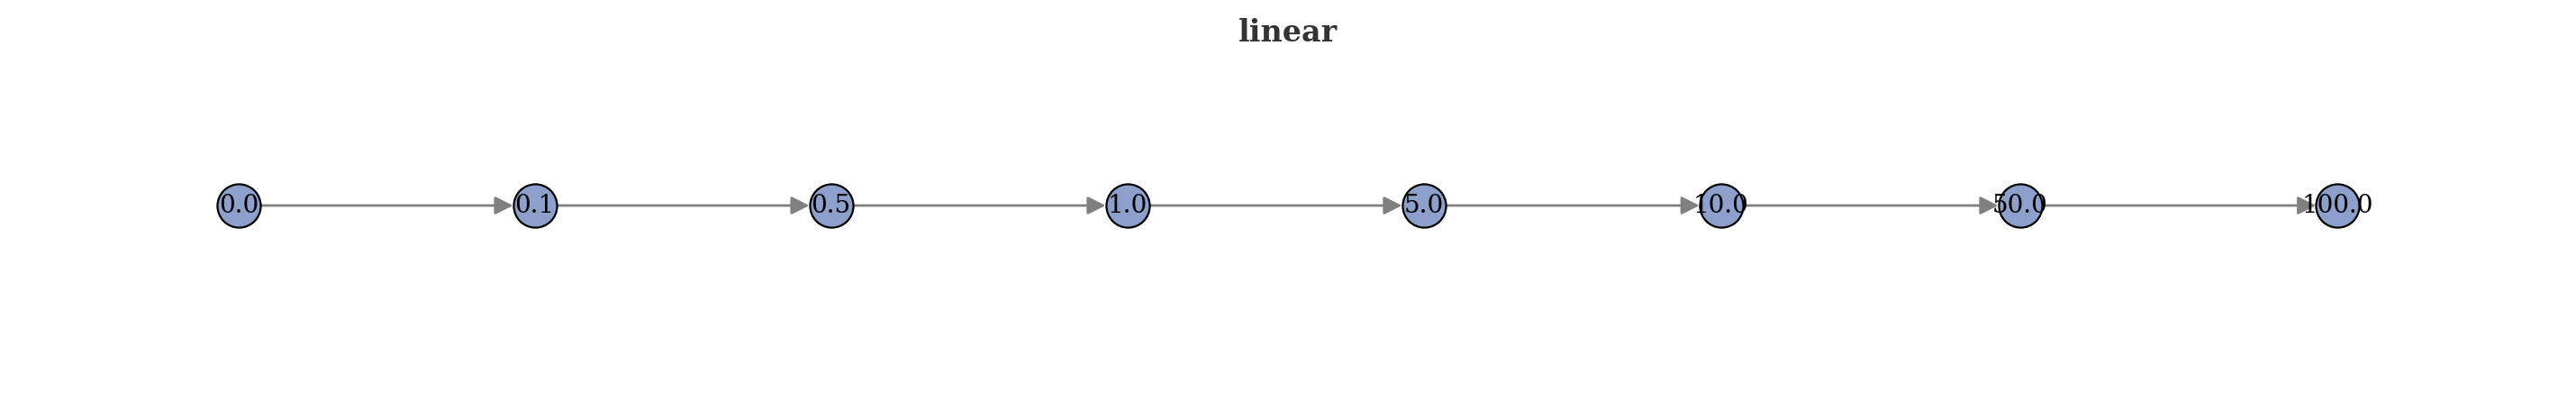

In [17]:
trajectory = "linear"
ground_truth_trajectories[trajectory] = [
    ('0.0', '0.1'),
    ('0.1', '0.5'),
    ('0.5', '1.0'),
    ('1.0', '5.0'),
    ('5.0', '10.0'),
    ('10.0', '50.0'),
    ('50.0', '100.0'),
]
_input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory, include_additional_nodes=False)
_input_trajectory.plot_trajectory(
    title=trajectory,
    figsize=(15, 2), 
    label_offset=0,
)

assert all([i in node_names for i in _input_trajectory.nodes()])

In [18]:
trajectory_object = InputTrajectories(ground_truth_trajectories)

definitions["tardis_sciplex_dose"]["trajectory_object_path"] = os.path.join(dataset_dir, f"tardis_cpa_sciplex_v2_encode_weight_scan_trajectory_object_dose.pkl")
with open(definitions["tardis_sciplex_dose"]["trajectory_object_path"], "wb") as _f:
    pickle.dump(trajectory_object, _f, protocol=pickle.HIGHEST_PROTOCOL)

## Check Definitions

In [19]:
definitions

{'tardis_sciplex_whole': {'training_anndata_path': '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/tardis_cpa_sciplex_v2_encode_incremental_training_anndata.h5ad',
  'vae_path': 'placeholder',
  'pickle_paths_path': '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/tardis_cpa_sciplex_v2_encode_weight_scan_latent_paths_whole.pkl',
  'trajectory_object_path': '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/tardis_cpa_sciplex_v2_encode_weight_scan_trajectory_object_whole.pkl',
  'label_obs_column': 'drug_dose_name',
  'batch_obs_column': 'none'},
 'tardis_sciplex_dose': {'training_anndata_path': '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/tardis_cpa_sciplex_v2_encode_incremental_training_anndata.h5ad',
  'vae_path': 'placeholder',
  'pickle_paths_path': '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/tardis_cpa_sciplex_v2_encode_weight_scan_latent_paths_dose.pkl',
  'trajectory_object_path': '/home/icb/kemal.inecik/lustre_workspace/temp_

# Running the benchmarking

```
#SBATCH -J {slurmjob_name}
#SBATCH -p cpu_p
#SBATCH --qos cpu_normal
#SBATCH -c 8
#SBATCH --mem=293G
#SBATCH --nice=0
#SBATCH -t 11:50:00
#SBATCH -o {log_file}
#SBATCH -e {log_file}

#SBATCH -J {slurmjob_name}
#SBATCH -p gpu_p
#SBATCH --qos=gpu_normal
#SBATCH --gres=gpu:1
#SBATCH -c 6
#SBATCH --mem=293G
#SBATCH --nice=0
#SBATCH -t 11:50:00
#SBATCH -o {log_file}
#SBATCH -e {log_file}
```

- for each coeff
- for each trajectory

### `scTRAM` package

In [20]:
pickle_paths_path = definitions["tardis_sciplex_dose"]["pickle_paths_path"]
with open(pickle_paths_path, "rb") as _file_pickle_paths:
    steps_paths_dict = pickle.load(_file_pickle_paths)
float(list(steps_paths_dict.keys())[0])

1.0

In [21]:
override = True
count = 0

for run_id in definitions.keys():

    pickle_paths_path = definitions[run_id]["pickle_paths_path"]
    with open(pickle_paths_path, "rb") as _file_pickle_paths:
        steps_paths_dict = pickle.load(_file_pickle_paths)    
    trajectory_path = definitions[run_id]["trajectory_object_path"]
    training_anndata_path = definitions[run_id]["training_anndata_path"]
    label_obs_column = definitions[run_id]["label_obs_column"]
    
    for weight_coef, latent_object_path in steps_paths_dict.items():
        
        with open(trajectory_path, "rb") as _file_trajectory_path:
            trajectories_object = pickle.load(_file_trajectory_path)
        
        for trajectory in sorted(trajectories_object.graph["trajectories"]):
            
            output_file_path = os.path.join(dataset_dir, f"metric_sctram_{run_id}_weight_{weight_coef}_trajectory_{trajectory}.pkl")
    
            log_file = os.path.join(logs_directory, f"slurm_out_metric_sctram_{run_id}_weight_{weight_coef}_trajectory_{trajectory}.log")
            slurmjob_name = f"sctram_{run_id}_{weight_coef}_{trajectory}"
            if override or not os.path.exists(output_file_path) or not os.path.isfile(output_file_path):
                try:
                    slurm_script = f"""#!/bin/bash
#SBATCH -J {slurmjob_name}
#SBATCH -p cpu_p
#SBATCH --qos cpu_normal
#SBATCH -c 4
#SBATCH --mem=60G
#SBATCH --nice=0
#SBATCH -t 8:50:00
#SBATCH -o {log_file}
#SBATCH -e {log_file}

source activate sctram_dev_env
python -u {os.path.join(helpers_directory, 'weight_scan_sctram.py')} --training_anndata_path "{training_anndata_path}" --label_obs_column "{label_obs_column}" --run_id "{run_id}" --steps_paths_dict "{pickle_paths_path}" --weight_coef "{weight_coef}" --trajectory_path "{trajectory_path}" --trajectory "{trajectory}" 
"""
                    slurm_script_name = os.path.join(logs_directory, f"slurm_job_metric_sctram_{run_id}_weight_{weight_coef}_trajectory_{trajectory}.sh")
                    with open(slurm_script_name, "w") as _file_slurm_script:
                        _file_slurm_script.write(slurm_script)
                    
                    print(f"Submitted job: sctram {run_id!r} weight {weight_coef!r} trajectory {trajectory!r}")
                    subprocess.run(["sbatch", slurm_script_name])
                    count += 1
                    # if count > 2:
                    #     raise ValueError
                finally:
                    # time.sleep(0.1)
                    os.remove(slurm_script_name)
                    pass
            else:
                print(f"Already exist: sctram {run_id!r} weight {weight_coef!r} trajectory {trajectory!r}")
print(f" - Number of jobs submitted: {count}")

Submitted job: sctram 'tardis_sciplex_whole' weight 1.0 trajectory 'complete'
Submitted batch job 36008823
Submitted job: sctram 'tardis_sciplex_whole' weight 1.0 trajectory 'fork'
Submitted batch job 36008824
Submitted job: sctram 'tardis_sciplex_whole' weight 1.0 trajectory 'linear'
Submitted batch job 36008825
Submitted job: sctram 'tardis_sciplex_whole' weight 1.0 trajectory 'linear_alternative'
Submitted batch job 36008826
Submitted job: sctram 'tardis_sciplex_whole' weight 0.975 trajectory 'complete'
Submitted batch job 36008827
Submitted job: sctram 'tardis_sciplex_whole' weight 0.975 trajectory 'fork'
Submitted batch job 36008828
Submitted job: sctram 'tardis_sciplex_whole' weight 0.975 trajectory 'linear'
Submitted batch job 36008829
Submitted job: sctram 'tardis_sciplex_whole' weight 0.975 trajectory 'linear_alternative'
Submitted batch job 36008830
Submitted job: sctram 'tardis_sciplex_whole' weight 0.95 trajectory 'complete'
Submitted batch job 36008831
Submitted job: sctra

In [22]:
definitions_path = os.path.join(dataset_dir, f"weight_scan_analysis_definitions_dict.pkl")
with open(definitions_path, "wb") as _f:
    pickle.dump(definitions, _f, protocol=pickle.HIGHEST_PROTOCOL)

In [24]:
0

0